# 04_01 Classification - LogisticRegression with CrossValidator

Train and evaluate Logistic Regression using k-fold CrossValidator (3-fold) for hyperparameter tuning.

**Note:** This notebook uses CrossValidator (k-fold CV) instead of TrainValidationSplit, satisfying UTIL-04 requirement.


## [COMMAND_SO]

Command 1

[COMMAND_MUC_DICH]

- Muc tieu nghiep vu: Train Logistic Regression voi CrossValidator (3-fold) va hien thi ket qua ro rang.
- Muc tieu ky thuat: Su dung CrossValidator thay vi TrainValidationSplit, so sanh CV vs TVS results.


In [2]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import time

# Spark session setup
spark = (SparkSession.builder
    .appName('04_01_lr_cv') # type: ignore
    .master('local[2]')
    .config('spark.sql.shuffle.partitions','16')
    .getOrCreate())
spark.sparkContext.setLogLevel('WARN')

# Paths
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
FEATURE_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'
MODEL_DIR = PROJECT_ROOT / 'models' / 'classification' / 'logistic_regression_cv_best'
METRIC_DIR = PROJECT_ROOT / 'reports' / 'model_metrics'
CROSSVAL_DIR = METRIC_DIR / 'crossvalidator'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
CROSSVAL_DIR.mkdir(parents=True, exist_ok=True)

# Load data
train_df = spark.read.parquet(str(FEATURE_DIR / 'classification_train')).select('order_id','label','features').dropna()
val_df = spark.read.parquet(str(FEATURE_DIR / 'classification_val')).select('order_id','label','features').dropna()
test_df = spark.read.parquet(str(FEATURE_DIR / 'classification_test')).select('order_id','label','features').dropna()

print(f"Train rows: {train_df.count()}, Val rows: {val_df.count()}, Test rows: {test_df.count()}")

Train rows: 68887, Val rows: 14546, Test rows: 14734


## Setup CrossValidator with ParamGrid

**CrossValidator Configuration:**

- numFolds=3 (k-fold cross-validation)
- Grid: regParam=[0.01, 0.1, 1.0], maxIter=[10, 50, 100]
- Metric: Accuracy (for CV optimization)
- parallelism=2 (LogisticRegression can run parallel)


In [3]:
# Define model
lr = LogisticRegression(featuresCol='features', labelCol='label', elasticNetParam=0.0)
# No setSeed for LogisticRegression in PySpark

# Build param grid (3x3 = 9 combinations)
param_grid = (
  ParamGridBuilder()
  .addGrid(lr.regParam, [0.01, 0.1, 1.0])
  .addGrid(lr.maxIter, [10, 50, 100])
  .build()
)

print(f"Total param combinations: {len(param_grid)}")

# Evaluator for CV (using accuracy for cross-validation optimization)
cv_evaluator = MulticlassClassificationEvaluator(
  labelCol='label',
  predictionCol='prediction',
  metricName='accuracy'
)

# CrossValidator setup
cv = CrossValidator(
  estimator=lr,
  estimatorParamMaps=param_grid,
  evaluator=cv_evaluator,
  numFolds=3,  # KEY: 3-fold cross-validation
  seed=42,
  parallelism=2  # LR can run parallel safely
)

print("CrossValidator configured:")
print(f"  - numFolds: 3")
print(f"  - parallelism: 2")
print(f"  - param combinations: {len(param_grid)}")
print(f"  - total models trained: {len(param_grid) * 3}")

Total param combinations: 9
CrossValidator configured:
  - numFolds: 3
  - parallelism: 2
  - param combinations: 9
  - total models trained: 27


## Run CrossValidator

This will train 27 models (9 param combos x 3 folds) and select the best.


In [4]:
# Fit CrossValidator
start_time = time.time()
print("Training CrossValidator (3-fold)...")

cv_model = cv.fit(train_df)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

# Get best model
best_model = cv_model.bestModel
best_regParam = best_model.getRegParam()
best_maxIter = best_model.getMaxIter()

print(f"\nBest params found:")
print(f"  regParam: {best_regParam}")
print(f"  maxIter: {best_maxIter}")

Training CrossValidator (3-fold)...


26/04/03 00:02:40 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/03 00:02:40 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Training completed in 5.75 seconds

Best params found:
  regParam: 0.01
  maxIter: 10


## Display All Param Combinations with CV Scores


In [5]:
# Extract param combinations and their avg CV scores
param_combos = []
for i, params in enumerate(param_grid):
    reg = params[lr.regParam]
    max_iter = params[lr.maxIter]
    avg_score = cv_model.avgMetrics[i]
    param_combos.append({
        'regParam': reg,
        'maxIter': max_iter,
        'cv_avg_accuracy': float(avg_score)
    })

cv_results_df = pd.DataFrame(param_combos)
cv_results_df = cv_results_df.sort_values('cv_avg_accuracy', ascending=False)

print("All parameter combinations with CV scores (sorted by accuracy):")
display(cv_results_df)

# Save detailed CV results
cv_results_df.to_csv(CROSSVAL_DIR / 'cv_logistic_regression.csv', index=False)
print(f"\nSaved to: {CROSSVAL_DIR / 'cv_logistic_regression.csv'}")

All parameter combinations with CV scores (sorted by accuracy):


,regParam,maxIter,cv_avg_accuracy
0,0.01,10,0.77148
1,0.01,50,0.77148
2,0.01,100,0.77148
3,0.10,10,0.77148
4,0.10,50,0.77148
5,0.10,100,0.77148
6,1.00,10,0.77148
7,1.00,50,0.77148
8,1.00,100,0.77148



Saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/crossvalidator/cv_logistic_regression.csv


## Evaluate Best Model on Validation and Test Sets


In [6]:
# Evaluate best model
pred_val = best_model.transform(val_df)
pred_test = best_model.transform(test_df)

# Metrics
val_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(pred_val)
val_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(pred_val)
test_f1 = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(pred_test)
test_acc = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(pred_test)

# CV average metric for best params
best_cv_avg = max(cv_model.avgMetrics)

metrics = {
    'model_family': 'classification',
    'model_name': 'LogisticRegression_CV',
    'tuning_method': 'CrossValidator',
    'num_folds': 3,
    'best_regParam': float(best_regParam),
    'best_maxIter': int(best_maxIter),
    'cv_avg_accuracy': float(best_cv_avg),
    'val_f1': float(val_f1),
    'val_accuracy': float(val_acc),
    'test_f1': float(test_f1),
    'test_accuracy': float(test_acc),
    'train_rows': train_df.count(),
    'val_rows': val_df.count(),
    'test_rows': test_df.count(),
    'training_time_seconds': float(training_time),
    'total_combinations': len(param_grid)
}

print("\nFinal Metrics:")
print(metrics)
display(pd.DataFrame([metrics]))


Final Metrics:
{'model_family': 'classification', 'model_name': 'LogisticRegression_CV', 'tuning_method': 'CrossValidator', 'num_folds': 3, 'best_regParam': 0.01, 'best_maxIter': 10, 'cv_avg_accuracy': 0.7714802330648376, 'val_f1': 0.6674715852898907, 'val_accuracy': 0.7681836931115084, 'test_f1': 0.6786282662928452, 'test_accuracy': 0.7763675851771413, 'train_rows': 68887, 'val_rows': 14546, 'test_rows': 14734, 'training_time_seconds': 5.751516103744507, 'total_combinations': 9}


,model_family,model_name,tuning_method,num_folds,best_regParam,best_maxIter,cv_avg_accuracy,val_f1,val_accuracy,test_f1,test_accuracy,train_rows,val_rows,test_rows,training_time_seconds,total_combinations
0,classification,LogisticRegression_CV,CrossValidator,3,0.01,10,0.77148,0.667472,0.768184,0.678628,0.776368,68887,14546,14734,5.751516,9


## Confusion Matrix


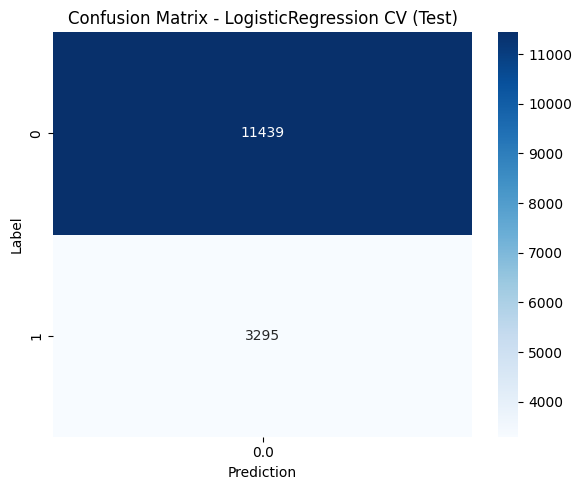

In [7]:
cm_pdf = pred_test.groupBy('label', 'prediction').count().toPandas()
if not cm_pdf.empty:
    cm_table = cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0).sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - LogisticRegression CV (Test)')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()

## CrossValidator vs TrainValidationSplit Comparison

Compare results with existing TVS implementation.


In [8]:
# Load TVS results
tvs_path = METRIC_DIR / 'tuning_classification_logistic_regression.json'
tvs_metrics = {}
if tvs_path.exists():
    with open(tvs_path) as f:
        tvs_data = json.load(f)
    # Load TVS test metrics from main metrics file
    tvs_main_path = METRIC_DIR / 'classification_logistic_regression.json'
    if tvs_main_path.exists():
        with open(tvs_main_path) as f:
            tvs_main = json.load(f)
        tvs_metrics = {
            'tvs_val_accuracy': tvs_main.get('val_accuracy', 'N/A'),
            'tvs_test_accuracy': tvs_main.get('test_accuracy', 'N/A'),
            'tvs_best_params': tvs_data.get('bestParams', {})
        }

# Create comparison
comparison = {
    'metric': ['Validation Accuracy', 'Test Accuracy', 'Best regParam', 'Best maxIter'],
    'CrossValidator_CV': [
        f"{best_cv_avg:.4f} (avg across 3 folds)",
        f"{test_acc:.4f}",
        f"{best_regParam}",
        f"{best_maxIter}"
    ],
    'TrainValidationSplit': [
        f"{tvs_metrics.get('tvs_val_accuracy', 'N/A')}",
        f"{tvs_metrics.get('tvs_test_accuracy', 'N/A')}",
        f"{tvs_metrics.get('tvs_best_params', {}).get('regParam', 'N/A')}",
        f"{tvs_metrics.get('tvs_best_params', {}).get('maxIter', 'N/A')}"
    ]
}

comparison_df = pd.DataFrame(comparison)
print("CrossValidator vs TrainValidationSplit Comparison:")
display(comparison_df)

# Save comparison
comparison_df.to_csv(CROSSVAL_DIR / 'cv_vs_tvs_logistic_regression.csv', index=False)

CrossValidator vs TrainValidationSplit Comparison:


,metric,CrossValidator_CV,TrainValidationSplit
0,Validation Accuracy,0.7715 (avg across 3 folds),0.7681836931115084
1,Test Accuracy,0.7764,0.7763675851771413
2,Best regParam,0.01,0.01
3,Best maxIter,10,80


## Save Model and Metrics


In [9]:
# Save best model
best_model.write().overwrite().save(str(MODEL_DIR))
print(f"Best model saved to: {MODEL_DIR}")

# Save metrics
metrics_path = METRIC_DIR / 'classification_logistic_regression_cv.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to: {metrics_path}")

# Save tuning report
tuning_report = {
    'model_family': 'classification',
    'model_name': 'LogisticRegression',
    'tuning_method': 'CrossValidator',
    'num_folds': 3,
    'metric': 'accuracy',
    'avgMetrics': [float(x) for x in cv_model.avgMetrics],
    'bestParams': {
        'regParam': float(best_regParam),
        'maxIter': int(best_maxIter)
    },
    'allParams': [
        {str(k.name): v for k, v in combo.items()}
        for combo in param_grid
    ]
}

tuning_path = METRIC_DIR / 'tuning_classification_logistic_regression_cv.json'
with open(tuning_path, 'w') as f:
    json.dump(tuning_report, f, indent=2)
print(f"Tuning report saved to: {tuning_path}")

print("\n✅ CrossValidator training complete!")

Best model saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/models/classification/logistic_regression_cv_best
Metrics saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/classification_logistic_regression_cv.json
Tuning report saved to: /Users/thuannguyen/Downloads/Vannhi/Nhom03_BigDataCuoiKy_Update_01/reports/model_metrics/tuning_classification_logistic_regression_cv.json

✅ CrossValidator training complete!
